In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"C:\Users\ADITYA\Downloads\Trip_advisor_review.csv") # Loading the spam dataset
                                                                       # Encoding is explicitly specified because real-world text datasets
                                                                       # often contain special characters that break UTF-8 decoding


In [4]:
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [5]:
df.shape

(20491, 2)

In [6]:
df.rename(columns = {"Review": "X" , "Rating" : "Y"}, inplace = True)
df.head(1)

,X,Y
0,nice hotel expensive parking got good deal sta...,4


In [7]:
df.replace({2:1, 3:2, 4:2,5:2}, inplace= True)

In [8]:
df.Y.unique()

array([2, 1])

In [9]:
import nltk
from nltk.corpus import stopwords

In [10]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADITYA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
len(stopwords.words("english"))

198

In [12]:
stopwords.words("english")

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [13]:
import string

In [14]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [15]:
l1 = stopwords.words("english")

def text_process(mess):                                     # creating a function
    """
    1. remove the punctuation                               ## a docstring
    2. remove the stop words.
    3. return the list of clean textwords

    """

    nopunc = [char for char in mess if char not in string.punctuation]
    nopunc = "".join(nopunc)
    return[word for word in nopunc.split() if word not in l1]

In [16]:
df.X.apply(text_process) # Invoke Function on each row

0        [nice, hotel, expensive, parking, got, good, d...
1        [ok, nothing, special, charge, diamond, member...
2        [nice, rooms, 4, experience, hotel, monaco, se...
3        [unique, great, stay, wonderful, time, hotel, ...
4        [great, stay, great, stay, went, seahawk, game...
                               ...                        
20486    [best, kept, secret, 3rd, time, staying, charm...
20487    [great, location, price, view, hotel, great, q...
20488    [ok, looks, nice, modern, outside, desk, staff...
20489    [hotel, theft, ruined, vacation, hotel, opened...
20490    [people, talking, ca, nt, believe, excellent, ...
Name: X, Length: 20491, dtype: object

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

In [18]:
var1 = CountVectorizer(analyzer = text_process).fit(df.X)

In [19]:
var1.vocabulary_

{'nice': 49206,
 'hotel': 36909,
 'expensive': 28378,
 'parking': 53208,
 'got': 33582,
 'good': 33347,
 'deal': 21915,
 'stay': 68556,
 'anniversary': 6999,
 'arrived': 8200,
 'late': 42141,
 'evening': 27588,
 'took': 73466,
 'advice': 5264,
 'previous': 56545,
 'reviews': 61027,
 'valet': 76980,
 'check': 16606,
 'quick': 57945,
 'easy': 25627,
 'little': 43220,
 'disappointed': 23592,
 'nonexistent': 49873,
 'view': 77537,
 'room': 61740,
 'clean': 17592,
 'size': 65815,
 'bed': 11090,
 'comfortable': 18553,
 'woke': 80136,
 'stiff': 68860,
 'neck': 48790,
 'high': 36036,
 'pillows': 54643,
 'soundproof': 67119,
 'like': 42920,
 'heard': 35439,
 'music': 48313,
 'night': 49383,
 'morning': 47723,
 'loud': 43892,
 'bangs': 9939,
 'doors': 24555,
 'opening': 51490,
 'closing': 17921,
 'hear': 35436,
 'people': 53896,
 'talking': 70917,
 'hallway': 34815,
 'maybe': 45647,
 'noisy': 49763,
 'neighbors': 48969,
 'aveda': 9092,
 'bath': 10462,
 'products': 57041,
 'goldfish': 33298,
 'to

In [20]:
len(var1.vocabulary_)

81408

In [21]:
df.X.shape

(20491,)

In [22]:
tdm = var1.transform(df.X)

In [23]:
tdm.shape

(20491, 81408)

In [24]:
# Logistic regression

In [25]:
from sklearn.model_selection import train_test_split
tdm_train, tdm_test , Y_train, Y_test = train_test_split(tdm, df.Y, test_size= .2)

In [26]:
from sklearn.linear_model import LogisticRegression
linreg = LogisticRegression()
linreg.fit(tdm_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:
pred = linreg.predict(tdm_test)

In [28]:
from sklearn.metrics import confusion_matrix,classification_report
tab = confusion_matrix(Y_test,pred)
tab

array([[ 463,  193],
       [ 132, 3311]])

In [29]:
print(classification_report(Y_test,pred))

              precision    recall  f1-score   support

           1       0.78      0.71      0.74       656
           2       0.94      0.96      0.95      3443

    accuracy                           0.92      4099
   macro avg       0.86      0.83      0.85      4099
weighted avg       0.92      0.92      0.92      4099



In [30]:
# Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier
Ranreg  = RandomForestClassifier()
Ranreg.fit(tdm_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
pred = Ranreg.predict(tdm_test)

In [33]:
from sklearn.metrics import confusion_matrix,classification_report
tab = confusion_matrix(Y_test,pred)
tab

array([[ 120,  536],
       [   5, 3438]])

In [34]:
print(classification_report(Y_test,pred))

              precision    recall  f1-score   support

           1       0.96      0.18      0.31       656
           2       0.87      1.00      0.93      3443

    accuracy                           0.87      4099
   macro avg       0.91      0.59      0.62      4099
weighted avg       0.88      0.87      0.83      4099



In [35]:
# Decision Tree

In [36]:
from sklearn.tree import DecisionTreeClassifier
Decreg = DecisionTreeClassifier()
Decreg.fit(tdm_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
pred = Decreg.predict(tdm_test)

In [38]:
from sklearn.metrics import confusion_matrix,classification_report
tab = confusion_matrix(Y_test,pred)
tab

array([[ 352,  304],
       [ 215, 3228]])

In [39]:
print(classification_report(Y_test,pred))

              precision    recall  f1-score   support

           1       0.62      0.54      0.58       656
           2       0.91      0.94      0.93      3443

    accuracy                           0.87      4099
   macro avg       0.77      0.74      0.75      4099
weighted avg       0.87      0.87      0.87      4099



In [138]:
df = pd.read_csv(r"C:\Users\ADITYA\Downloads\Trip_advisor_review.csv") 
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


# 1 Vader_lexicon :- It is an inbuilt model which does the sentimental Analysis

In [139]:
df1 = df['Review']

In [140]:
df1.head()

0    nice hotel expensive parking got good deal sta...
1    ok nothing special charge diamond member hilto...
2    nice rooms not 4* experience hotel monaco seat...
3    unique, great stay, wonderful time hotel monac...
4    great stay great stay, went seahawk game aweso...
Name: Review, dtype: object

In [49]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [50]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ADITYA\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [52]:
sent = SentimentIntensityAnalyzer()

In [54]:
sent_score = []
for i in range (0, df1.shape[0]):
    result = sent.polarity_scores(df1[i])
    sent_score.append(result['compound'])    

In [55]:
sent_score

[0.9747,
 0.9787,
 0.9889,
 0.9912,
 0.9797,
 0.987,
 0.9925,
 0.959,
 0.9618,
 0.9756,
 0.9666,
 0.9242,
 0.9859,
 0.7584,
 0.9608,
 0.8496,
 0.9905,
 0.9948,
 0.93,
 0.9891,
 0.9754,
 0.9831,
 0.9661,
 0.969,
 0.9153,
 0.9509,
 0.9753,
 -0.3814,
 0.9954,
 0.9336,
 0.9839,
 0.9468,
 0.8716,
 0.8874,
 0.9022,
 0.9884,
 0.9913,
 0.9586,
 0.954,
 0.9565,
 -0.9249,
 0.9274,
 -0.9169,
 0.9796,
 -0.1561,
 0.9829,
 0.8413,
 0.7592,
 0.9776,
 0.9526,
 0.9782,
 0.9895,
 0.977,
 0.9578,
 0.5563,
 0.8842,
 0.9549,
 0.9936,
 0.9703,
 0.9962,
 0.9847,
 0.9872,
 0.9915,
 0.9913,
 0.9872,
 -0.936,
 0.9932,
 0.9904,
 0.7351,
 0.3182,
 0.9441,
 -0.9228,
 0.9957,
 0.9669,
 0.9872,
 0.9929,
 -0.4261,
 -0.2023,
 0.9158,
 -0.743,
 0.9507,
 0.9656,
 0.9882,
 0.6846,
 0.9648,
 0.9403,
 0.9712,
 0.9568,
 -0.8889,
 0.9559,
 0.9304,
 0.9285,
 0.9148,
 0.9531,
 0.9833,
 0.9761,
 0.9097,
 0.235,
 0.9771,
 -0.9065,
 0.9727,
 0.6483,
 0.9982,
 0.8412,
 0.9859,
 0.9687,
 0.9643,
 0.9792,
 0.9978,
 0.8689,
 0.9968,


In [57]:
# perform the Analytics on sent_score
# Analytics easy if it is in Dataframe
pd.DataFrame(sent_score).describe()

,0
count,20491.000000
mean,0.803430
std,0.455671
min,-0.997400
25%,0.918400
50%,0.973800
75%,0.988800
max,0.999900


# 2 textblob :- It is an inbuilt model which does the sentimental Analysis

In [61]:
from textblob import TextBlob

In [62]:
blob = TextBlob("movie was worse")
answer = blob.sentiment
answer

Sentiment(polarity=-0.4, subjectivity=0.6)

In [141]:
sent_score = []
for i in range(0 , df.shape[0]):
    blob = TextBlob(str(df.Review[i]))
    answer = blob.sentiment
    sent_score.append(answer[0])

sent_score_blob = []
for i in range (0, df1.shape[0]):
    result = sent.polarity_scores(df1[i])
    answer =  blob.sentiment
    sent_score_blob.append(answer[0]) 
    if i % 1000 == 0:       # to check if the code is running or not
        print(i)

In [143]:
sent_score_blob

[-0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,
 -0.4,

In [144]:
pd.DataFrame(sent_score).describe()

,0
count,20491.000000
mean,0.274278
std,0.181452
min,-1.000000
25%,0.177426
50%,0.280371
75%,0.384903
max,1.000000


In [72]:
from nltk.corpus import wordnet
from nltk.wsd import lesk  # It is for Disambiguation
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADITYA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ADITYA\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADITYA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [75]:
context_sentence = "light helps seeing object"
tokens = nltk.word_tokenize(context_sentence)
tokens

['people', 'go', 'swimming', 'on', 'banks', 'of', 'ocean']

In [79]:
word = "light"
sense = lesk(tokens, word)
sense.definition()

'the visual effect of illumination on objects or scenes as created in pictures'

# NER(Name Entity Recognition)

In [ ]:
# Stanford University
# Stanza --> Model for NER

In [80]:
#pip install stanza

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 9.3 MB/s  0:00:00
   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
    --------------------------------------- 1.8/113.7 MB 11.2 MB/s eta 0:00:10
   - -------------------------------------- 4.2/113.7 MB 11.0 MB/s eta 0:00:10
   -- ------------------------------------- 6.8/113.7 MB 11.3 MB/s eta 0:00:10
   --- ------------------------------------ 9.2/113.7 MB 11.4 MB/s eta 0:00:10
   ---- ----------------------------------- 11.8/113.7 MB 11.5 MB/s eta 0:00:09
   ---- ----------------------------------- 13.9/113.7 MB 11.5 MB/s eta 0:00:09
   ----- ---------------------------------- 16.3/113.7 MB 11.5 MB/s eta 0:00:09
   ------ --------------------------------- 18.9/113.7 MB 11.6 MB/s eta 0:00:09
   ------- -------------------------------- 21.0/113.7 MB 11.5 MB/s eta 0:00:09
   -------- ------------------------------- 23.6/113.7 MB 11.6 MB/s eta

In [82]:
import stanza
stanza.download('en')
nlp = stanza.Pipeline(lang='en', processors="tokenize,ner")

2026-02-08 11:46:59 INFO: Downloaded file to C:\Users\ADITYA\stanza_resources\resources.json
2026-02-08 11:46:59 INFO: Downloading default packages for language: en (English) ...


2026-02-08 11:48:14 INFO: Downloaded file to C:\Users\ADITYA\stanza_resources\en\default.zip
2026-02-08 11:48:17 INFO: Finished downloading models and saved to C:\Users\ADITYA\stanza_resources
2026-02-08 11:48:17 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-02-08 11:48:17 INFO: Downloaded file to C:\Users\ADITYA\stanza_resources\resources.json
2026-02-08 11:48:17 WARNING: Language en package default expects mwt, which has been added
2026-02-08 11:48:18 INFO: Loading these models for language: en (English):
| Processor | Package                   |
-----------------------------------------
| tokenize  | combined                  |
| mwt       | combined                  |
| ner       | ontonotes-ww-multi_charlm |

2026-02-08 11:48:18 INFO: Using device: cpu
2026-02-08 11:48:18 INFO: Loading: tokenize
2026-02-08 11:48:19 INFO: Loading: mwt
2026-02-08 11:48:19 INFO: Loading: ner
2026-02-08 11:48:24 INFO: Done loading processors!


In [83]:
doc = nlp("Mumbai is in Maharastra")
for ent in doc.entities:
    print(ent.text, "||",ent.type)

Mumbai || GPE
Maharastra || GPE


In [84]:
doc = nlp("GDP of India is around 5 Trilllion USD")
for ent in doc.entities:
    print(ent.text, "||",ent.type)

India || GPE
5 Trilllion USD || MONEY


In [85]:
doc = nlp("Today is sunday and the it's 1 p.m now")
for ent in doc.entities:
    print(ent.text, "||",ent.type)

Today || DATE
sunday || DATE
1 p.m || TIME


In [87]:
doc = nlp("Apple is a company with 1 Trillon $")
for ent in doc.entities:
    print(ent.text, "||",ent.type)

Apple || ORG
1 Trillon $ || MONEY


In [92]:
doc = nlp("it is 10 at clock tower at malaysia is famous for its beaches")
for ent in doc.entities:
    print(ent.text, "||",ent.type)

10 || CARDINAL
malaysia || GPE


In [93]:
doc = nlp("India and Pakistan are neighbours")
for ent in doc.entities:
    print(ent.text, "||",ent.type)

India || GPE
Pakistan || GPE


In [96]:
doc = nlp("Ganga ,Yamuna meet at confluence of Prayagraj")
for ent in doc.entities:
    print(ent.text, "||",ent.type)

Ganga || PERSON
Yamuna || GPE
Prayagraj || GPE


# Word Cloud

In [ ]:
# 5 word cloud ---> pictorial representation of the most frequent(count) words

In [ ]:
# resume of data science
# which are needed in industry --> JD
# 30 JD for data Science --> word cloud on 

In [ ]:
# supervised
# unsupervised
# SQL
# Python
# ML, Power BI, Regression, NLP

In [ ]:
# In your word cloud if the frequecy or word is more the font size will also be more

In [98]:
#pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


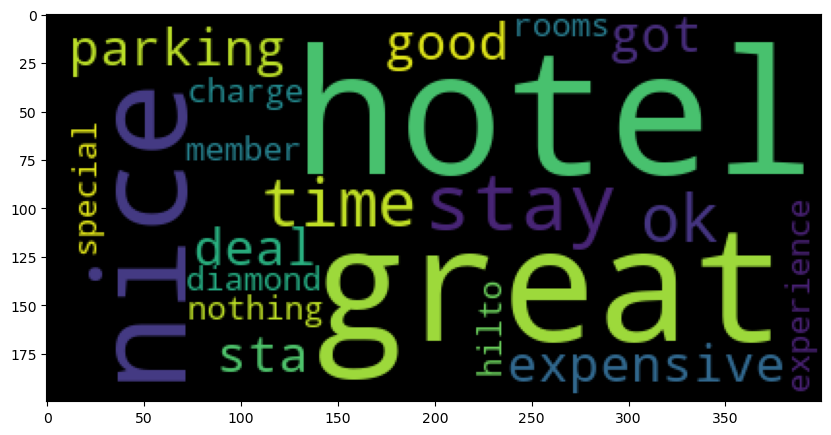

In [101]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

cloud = WordCloud(stopwords= stopwords.words("english"),max_words= 20).generate(str(df['X']))
plt.figure(figsize=(10,20))
plt.imshow(cloud)

In [107]:
with open(r"C:\Users\ADITYA\Downloads\Budget2026.txt", encoding = "utf-8") as file:
    text = file.read()

In [108]:
text

'GOVERNMENT OF INDIA\nBUDGET 2026-2027\nSPEECH\nOF\nNIRMALA SITHARAMAN\nMINISTER OF FINANCE\nFebruary 1, 2026\nCONTENTS\nPage No.\nIntroduction 1\n PART - A\nYuva Shakti and 3 kartavya 2\nReform Express 3\nFirst kartavya: to accelerate and sustain economic growth 3\nSecond kartavya: fulfil aspirations and build capacity 10\nThird kartavya: Sabka Sath, Sabka Vikas 14\n16th Finance Commission 18\nFiscal Consolidation 18\nPART – B\nDirect taxes 20\nIndirect Taxes 26\nAnnexure to Part-A 32\nAnnexure to Part-B\nAmendments relating to Direct Taxes 33\nAmendments relating to Indirect Taxes 50\nBudget 2026-2027\nSpeech of\nNirmala Sitharaman\nMinister of Finance\nFebruary 1, 2026\nHon’ble Speaker,\nOn the sacred occasion of Magha Purnima and the birth\nanniversary of Guru Ravidas, I present the Budget for the year 2026-2027.\nIntroduction\n1. Since we assumed office 12 years ago, India’s economic trajectory\nhas been marked by stability, fiscal discipline, sustained growth and\nmoderate inflat

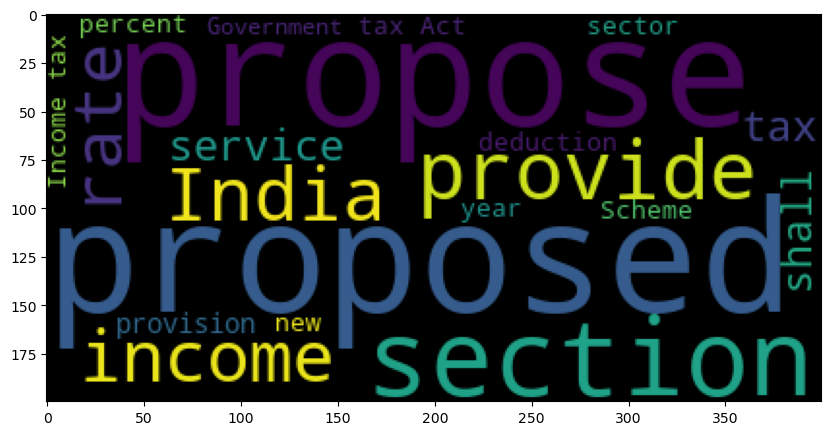

In [110]:

cloud = WordCloud(stopwords= stopwords.words("english"),max_words= 20).generate(text)
plt.figure(figsize=(10,20))
plt.imshow(cloud)

In [116]:
import nltk
from nltk import FreqDist

In [117]:
l1 = stopwords.words("english")

In [118]:
words = [w for w in text.split() if w.lower() not in l1]
len(set(words))

4360

In [119]:
fdist = FreqDist(words)
top_30 = fdist.most_common(30)

In [120]:
top_30

[('proposed', 100),
 ('propose', 95),
 ('tax', 79),
 ('\uf0b7', 77),
 ('provide', 59),
 ('section', 58),
 ('Act,', 54),
 ('income', 53),
 ('shall', 40),
 ('also', 37),
 ('rate', 36),
 ('India', 34),
 ('new', 34),
 ('goods', 32),
 ('percent', 32),
 ('No.', 31),
 ('duty', 30),
 ('manufacture', 29),
 ('deduction', 28),
 ('period', 28),
 ('use', 27),
 ('services', 26),
 ('support', 25),
 ('penalty', 24),
 ('exemption', 24),
 ('Customs', 24),
 ('global', 23),
 ('Indian', 23),
 ('lakh', 23),
 ('provisions', 23)]

# 8 Stemming

In [125]:
from nltk.stem import PorterStemmer


In [126]:
stem = PorterStemmer()

In [134]:
stem.stem("Thinking")

'think'